<a href="https://colab.research.google.com/github/ninaslindgren/Data-portfolio/blob/main/Python-myyntianalyysi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python-myyntianalyysi

Tässä projektissa analysoidaan kuvitteellisen verkkokaupan myyntidataa Pythonilla.

## Tavoite

Tavoitteena on selvittää myynnin ja kannattavuuden kehitystä sekä tunnistaa parhaiten menestyvät tuotteet, tuoteryhmät ja myyntikanavat.

## Käytetyt työkalut

- Python
- Pandas
- Matplotlib
- Google Colab

## 1. Aineiston tarkastelu

In [1]:
import pandas as pd

# Luetaan myyntidata
df = pd.read_csv("python_myyntianalyysi_data.csv")

# Näytetään 5 ensimmäistä riviä
df.head()

,TilausID,Tilauspäivä,AsiakasID,TuoteID,Tuote,Tuoteryhmä,Määrä,Yksikköhinta,Alennus_prosentti,Myynti,Kustannus,Kate,Kaupunki,Myyntikanava,Maksutapa
0,T00001,2025-04-25,A0072,P001,Langattomat kuulokkeet,Elektroniikka,2,89.9,0,179.80,94.0,85.80,Espoo,Verkkokauppa,PayPal
1,T00002,2025-02-02,A0309,P001,Langattomat kuulokkeet,Elektroniikka,1,89.9,0,89.90,47.0,42.90,Helsinki,Google,PayPal
2,T00003,2025-08-14,A0004,P008,LED-pöytävalaisin,Koti,1,44.9,10,40.41,20.0,20.41,Vantaa,Sähköposti,Verkkopankki
3,T00004,2025-10-12,A0053,P003,Älykello,Elektroniikka,1,129.9,10,116.91,72.0,44.91,Espoo,Sähköposti,Kortti
4,T00005,2026-01-03,A0023,P014,Reppu 20L,Asusteet,1,64.9,0,64.90,31.0,33.90,Kuopio,Verkkokauppa,PayPal


## 2. Kokonaismyynti ja kokonaiskate

In [2]:
# Myynti ja kate yhteensä

kokonaismyynti = df["Myynti"].sum()
kokonaiskate = df["Kate"].sum()

print("Kokonaismyynti:", round(kokonaismyynti, 2), "€")
print("Kokonaiskate:", round(kokonaiskate, 2), "€")

Kokonaismyynti: 137394.05 €
Kokonaiskate: 69474.55 €


## 3. TOP 10 tuotteet

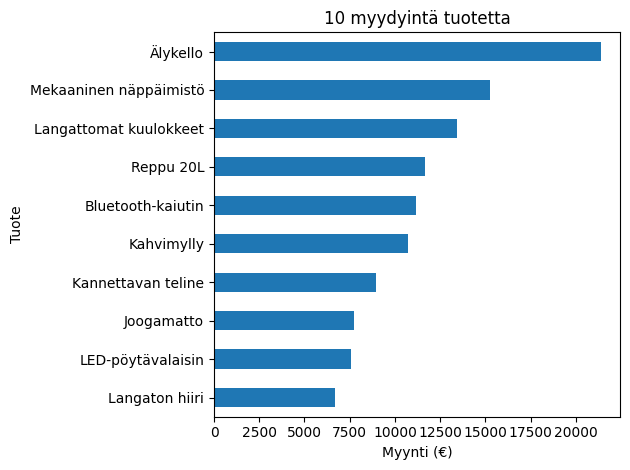

In [3]:
import matplotlib.pyplot as plt

# Lasketaan myynti tuotteittain
top10 = (
    df.groupby("Tuote")["Myynti"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Piirretään pylväsdiagrammi
top10.sort_values().plot(kind="barh")

plt.title("10 myydyintä tuotetta")
plt.xlabel("Myynti (€)")
plt.ylabel("Tuote")
plt.tight_layout()
plt.show()

## 4. Myynnin kehitys kuukausittain

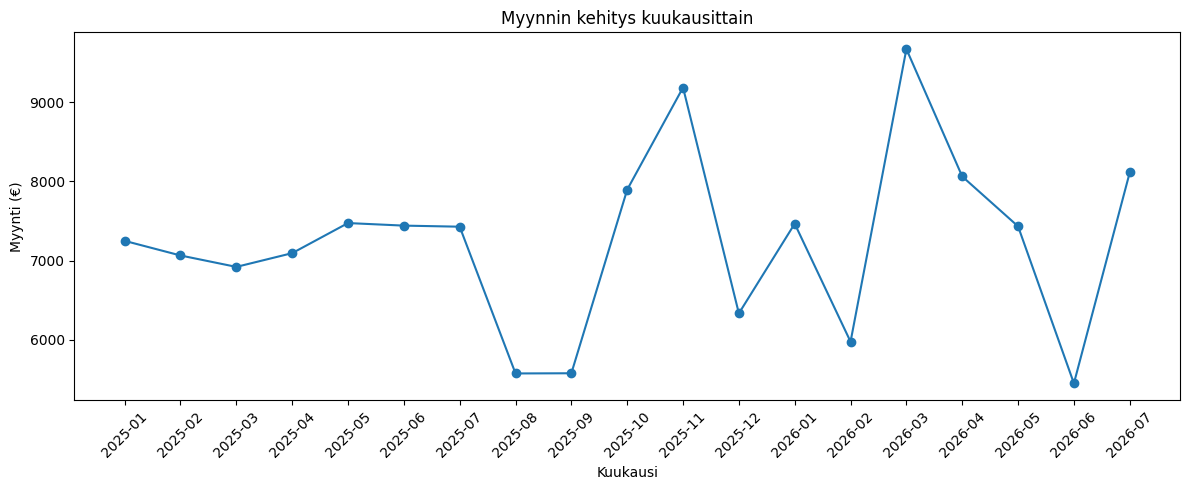

In [4]:
# Muutetaan tilauspäivä päivämääräksi
df["Tilauspäivä"] = pd.to_datetime(df["Tilauspäivä"])

# Lasketaan myynti kuukausittain
kuukausimyynti = (
    df.groupby(df["Tilauspäivä"].dt.to_period("M"))["Myynti"]
    .sum()
)

# Muutetaan kuukausi tekstiksi kuvaajaa varten
kuukausimyynti.index = kuukausimyynti.index.astype(str)

# Piirretään kuvaaja
plt.figure(figsize=(12, 5))
plt.plot(kuukausimyynti.index, kuukausimyynti.values, marker="o")

plt.title("Myynnin kehitys kuukausittain")
plt.xlabel("Kuukausi")
plt.ylabel("Myynti (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Kate tuoteryhmittäin

Tuoteryhmä
Elektroniikka    23647.64
Työpiste         15410.11
Koti             12096.45
Hyvinvointi       9184.84
Asusteet          9135.51
Name: Kate, dtype: float64


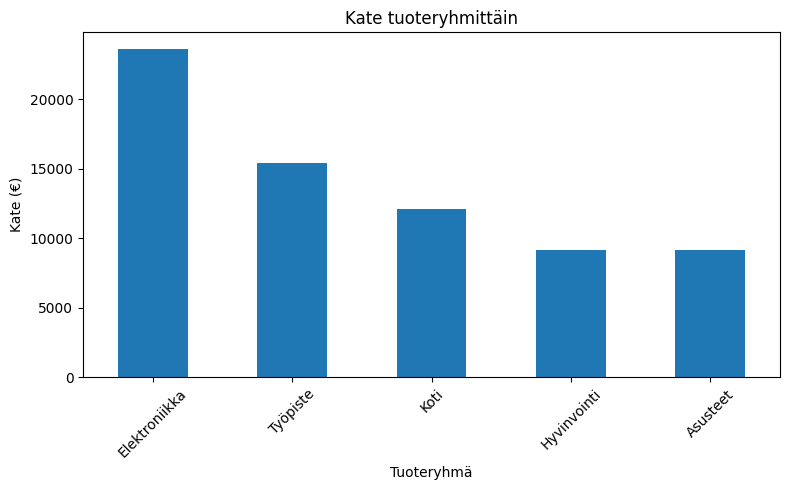

In [5]:
# Lasketaan kate tuoteryhmittäin
tuoteryhma_kate = (
    df.groupby("Tuoteryhmä")["Kate"]
    .sum()
    .sort_values(ascending=False)
)

print(tuoteryhma_kate)

# Piirretään pylväsdiagrammi
plt.figure(figsize=(8, 5))

tuoteryhma_kate.plot(kind="bar")

plt.title("Kate tuoteryhmittäin")
plt.xlabel("Tuoteryhmä")
plt.ylabel("Kate (€)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 6. Myynti myyntikanavittain

Myyntikanava
Sähköposti           38014.37
Google               35068.22
Verkkokauppa         32713.11
Sosiaalinen media    31598.35
Name: Myynti, dtype: float64


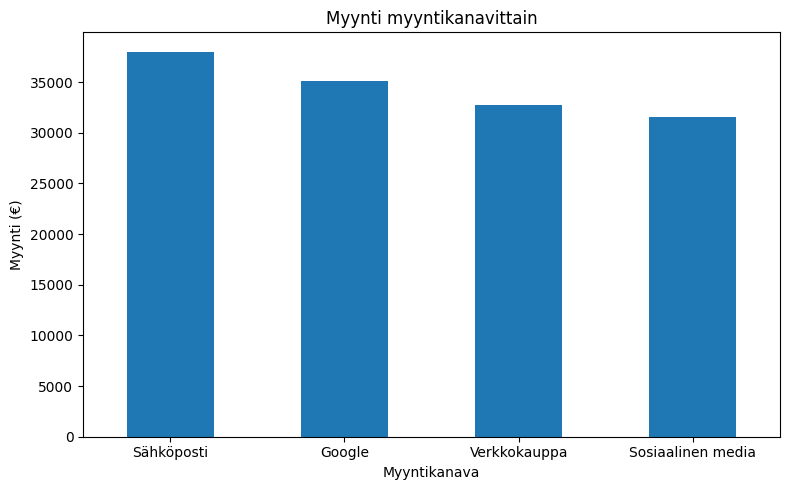

In [6]:
# Lasketaan myynti myyntikanavittain
kanavamyynti = (
    df.groupby("Myyntikanava")["Myynti"]
    .sum()
    .sort_values(ascending=False)
)

print(kanavamyynti)

# Piirretään pylväsdiagrammi
plt.figure(figsize=(8, 5))

kanavamyynti.plot(kind="bar")

plt.title("Myynti myyntikanavittain")
plt.xlabel("Myyntikanava")
plt.ylabel("Myynti (€)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Johtopäätökset

Analysoidun aineiston kokonaismyynti oli 137 394,05 € ja kokonaiskate 69 474,55 €.

- Älykello oli myynniltään paras tuote, ja sen myynti oli 21 368,64 €.
- Elektroniikka oli kannattavin tuoteryhmä 23 647,64 €:n kokonaiskatteella.
- Sähköposti oli myynniltään suurin myyntikanava, jonka kautta kertyi 38 014,37 € myyntiä.
- Maaliskuu 2026 oli tarkastelujakson paras myyntikuukausi 9 673,63 €:n myynnillä.

Tulosten perusteella elektroniikkatuotteilla on merkittävä rooli yrityksen myynnissä ja kannattavuudessa. Lisäksi sähköpostikanavan vahva tulos viittaa siihen, että sitä kannattaa hyödyntää aktiivisesti markkinoinnissa ja asiakasviestinnässä.

In [8]:
# Yhteenveto tärkeimmistä havainnoista

print("Kokonaismyynti:", round(df["Myynti"].sum(), 2), "€")
print("Kokonaiskate:", round(df["Kate"].sum(), 2), "€")

print("\nMyydyin tuote:")
print(top10.head(1))

print("\nKannattavin tuoteryhmä:")
print(tuoteryhma_kate.head(1))

print("\nSuurin myyntikanava:")
print(kanavamyynti.head(1))

print("\nParas myyntikuukausi:")
print(kuukausimyynti.sort_values(ascending=False).head(1))

Kokonaismyynti: 137394.05 €
Kokonaiskate: 69474.55 €

Myydyin tuote:
Tuote
Älykello    21368.64
Name: Myynti, dtype: float64

Kannattavin tuoteryhmä:
Tuoteryhmä
Elektroniikka    23647.64
Name: Kate, dtype: float64

Suurin myyntikanava:
Myyntikanava
Sähköposti    38014.37
Name: Myynti, dtype: float64

Paras myyntikuukausi:
Tilauspäivä
2026-03    9673.63
Name: Myynti, dtype: float64
